# Keras
Librería para programar redes neuronales de una manera más sencilla que con TensorFlow. Keras se encuentra en una capa de abstracción por encima de TensorFlow.

[Documentación](https://keras.io/guides/)

In [1]:
# %pip install tensorflow keras

   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/350.8 MB 5.3 MB/s eta 0:01:07
   ---------------------------------------- 0.5/350.8 MB 6.3 MB/s eta 0:00:56
   ---------------------------------------- 1.1/350.8 MB 8.7 MB/s eta 0:00:41
   ---------------------------------------- 1.5/350.8 MB 9.4 MB/s eta 0:00:38
   ---------------------------------------- 1.7/350.8 MB 7.6 MB/s eta 0:00:46
   ---------------------------------------- 2.6/350.8 MB 9.8 MB/s eta 0:00:36
   ---------------------------------------- 3.1/350.8 MB 10.0 MB/s eta 0:00:35
   ---------------------------------------- 3.2/350.8 MB 8.8 MB/s eta 0:00:40
   ---------------------------------------- 4.1/350.8 MB 10.5 MB/s eta 0:00:34
    --------------------------------------- 4.7/350.8 MB 10.4 MB/s eta 0:00:34
    --------------------------------------- 5.2/350.8 MB 10.4 MB/s eta 0:00:34
    --------------------------------------- 5.7/350.8 MB 10.4 MB/s 


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## Si tienes una gráfica Nvidia
# %pip install tensorflow[and-cuda] keras

Empezamos importando librerías

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np

Cargamos los datos de mnist. No vamos a tratar imagenes con redes convolucionales (perdemos la estructura espacial 2D). Todos los pixeles se convertirán en un vector de 28x28 features independientes, que serán las entradas del modelo.

In [3]:
# Cogemos las imágenes de los dígitos asi como el conjunto de train y test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Vemos dimensiones del dataset

In [4]:
'''
60.000 imagenes de 28x28 pixeles
'''
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [5]:
len(np.unique(y_test))

10

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
2**8 # niveles de gris

256

60.000 imágenes de 28x28 pixeles. Vamos a representar una de ellas

C:\Users\titea\AppData\Local\Temp\ipykernel_2168\3096108358.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));


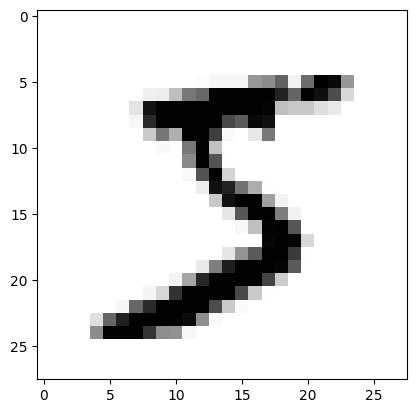

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap=plt.cm.get_cmap('Greys'));

Cada imagen se compone de 28x28 pixeles, y cada pixel representa una escala de grises que va del 0 al 255. Siendo 0 el blanco y 255 negro.

¿Se te ocurre alguna manera de normalizar los datos?

In [9]:
np.max(X_train)

np.uint8(255)

In [10]:
0/255

0.0

In [11]:
128/255

0.5019607843137255

In [12]:
255/255

1.0

In [13]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [ ]:
np.mean(X_train) # nivel de gris medio es de 0.13

np.float32(0.13066047)

In [15]:
'''
Comprobamos la normalización
'''
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [16]:
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

Guardamos datos para validación. Estos datos se usarán durante el entrenamiento. Otra opción es decirle a keras en la etapa de entrenamiento que reserve un X % de los datos para validar.

In [17]:
X_val = X_train[-10000:]
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [ ]:
print(X_train.shape)
print(X_val.shape) # guardo otra parte de datos para validation, es para hacer alguna comprobación de overfit
print(X_test.shape)

(50000, 28, 28)
(10000, 28, 28)
(10000, 28, 28)


Montamos la arquitectura de la red neuronal. Se va a componer de:
* **Sequential**: API para iniciar la red neuronal. No cuenta como capa.
* **Flatten**: capa de entrada. Necesita un vector unidimensional. Como tenemos imágenes, esta capa aplana las imagenes (2D) en 1D.
* **Dense**: es una hidden layer. Se compondrá de `n` neuronas y de una función de activación que se aplicará a todas las neuronas de la capa.

Recuerda que es un problema de clasificación multiclase (10 clases) y que por tanto la última capa se compondrá de tantas neuronas como clases tengas.

En cuanto a las funciones de activación es recomendable usar relu en las hidden layer, que tarda menos en entrenar, mientras que la ultima (output) suele ser una softmax.

In [19]:
28*28

784

In [20]:
X_train.shape

(50000, 28, 28)

In [ ]:
model = keras.models.Sequential()

# Capa entrada
model.add(keras.layers.Flatten(input_shape=(28, 28)))

# Hidden layer
model.add(keras.layers.Dense(units = 300,
                            activation='relu'))

# Hidden layer
model.add(keras.layers.Dense(units = 100,
                            activation='relu'))

# Capa salida
model.add(keras.layers.Dense(units = 10,
                            activation='softmax')) # softmax xq es clasificacion multiclase # binaria sigmoide


c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
# Otra manera de declarar la red neuronal
capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]

model = keras.models.Sequential(capas)

Podemos ver las capas, y acceder a sus elementos

In [ ]:
print(model.layers[0])

# primera capa de flaterizacion

<Flatten name=flatten_1, built=True>


Podemos ver los pesos de las capas sin entrenar, porque los inicializa aleatoriamente. Los bias los inicializa a 0.

In [24]:
hidden1 = model.layers[1]
weights, biases = hidden1.get_weights()

In [ ]:
weights

# de moemto tiene esos pesos, no está entrenada

array([[-0.00093038, -0.05382172, -0.05554969, ..., -0.01172552,
        -0.0339016 , -0.04558519],
       [-0.04265888, -0.06946684, -0.01708618, ...,  0.03874885,
        -0.00790699,  0.01148733],
       [-0.07134142,  0.0615094 ,  0.00945672, ..., -0.0189718 ,
        -0.04297009, -0.05000699],
       ...,
       [-0.00351678,  0.07033065,  0.03755143, ..., -0.00019794,
        -0.01313428,  0.07371148],
       [-0.0190363 ,  0.05862087,  0.01171757, ..., -0.05203644,
         0.03013793,  0.04904261],
       [ 0.01971802, -0.00937431,  0.03445234, ..., -0.00977482,
         0.074359  ,  0.07001586]], shape=(784, 300), dtype=float32)

In [ ]:
len(weights)

# 784 pesos en toda la red

784

In [ ]:
len(weights[0])

# capa 1

300

In [ ]:
28*28

# le meto 784 features

784

In [ ]:
300*784

# peso capa 1 x features

# son 235200 parámetros

235200

In [ ]:
weights.size
# son 235200 parámetros a ajustar

235200

In [31]:
len(biases)

300

Establecemos la configuración de ejecución... el compile.

In [ ]:
model.compile(
    optimizer = keras.optimizers.SGD(),
    loss = keras.losses.SparseCategoricalCrossentropy(), # SparseCategoricalCrossentropy() medida de funcion cuanto tiens una clasificacion multiclase
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

In [ ]:
# Equivalente
model.compile(
    optimizer = "sgd",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# Summary
model.summary()

# 1a capa de flater param 0 xq no ajustas nada, una neurona x feature
# 300 neuronas y recibe 784 entradas, más los 300 de los poripios sesgos de las neuronas = 235000 parametros
# 300*100 + 100 = 30,100
# 100*10 + 10 = 1,010


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
784 * 300 + 300

235500

In [ ]:
# 1º neurona de la 1º hidden layer
# y = a + w1*x1 + w2*x2 + .... wn*xn
# a es el intercepto llamado bias
# wn es cada uno de los pesos que va a ir actualizando con el backpropagation
# n es 784
# En la 1º hidden layer tenemos 784 pesos por cada neurona, al tener 300, tenemos un total de:
print(784*300 + 300)

235500


In [ ]:
300 * 784 + 300

235500

In [ ]:
300 * 100 + 100

30100

In [ ]:
100 * 10 + 10

1010

Entrenamos el modelo. Usamos los datos de entrenamiento. El batch_size es la cantidad de muestras que utiliza el SGD, y las epochs son las iteraciones que realiza en el entrenamiento.

In [ ]:
X_train.shape

(11610, 8)

In [ ]:
50000/128

390.625

In [83]:
history = model.fit(
    X_train,
    y_train,
    batch_size = 128,
    epochs = 50,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/50


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\titea\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\titea\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\titea\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\titea\AppData\Roaming\Python\Python311\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 608, in run_forever

  File "c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\asynci

Podemos reentrenar el modelo. No empieza de nuevo, sino que retoma el entrenamiento anterior.

In [ ]:
model.fit(
    X_train,
    y_train,
    batch_size = 64,
    epochs = 10,
    validation_data = (X_val, y_val) # validation_split = 0.1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9772 - loss: 0.0835 - val_accuracy: 0.9709 - val_loss: 0.1071
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9784 - loss: 0.0806 - val_accuracy: 0.9714 - val_loss: 0.1047
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9791 - loss: 0.0779 - val_accuracy: 0.9722 - val_loss: 0.1018
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9802 - loss: 0.0749 - val_accuracy: 0.9728 - val_loss: 0.1005
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9807 - loss: 0.0725 - val_accuracy: 0.9723 - val_loss: 0.0994
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9815 - loss: 0.0700 - val_accuracy: 0.9730 - val_loss: 0.0988
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9822 - loss: 0.0676 - val_accuracy: 0.9730 - val_loss: 0.0971
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9827 - loss: 0.0653 - val_accuracy: 0.

Veamos el histórico del entrenamiento, para poder representarlo posteriormente.

In [ ]:
# print(history.params)
# print(history.epoch)
print(history.history)

{'accuracy': [0.6648600101470947, 0.8644599914550781, 0.88919997215271, 0.9002799987792969, 0.9083999991416931, 0.9142799973487854, 0.9190999865531921, 0.9235000014305115, 0.9272199869155884, 0.9301199913024902, 0.9339600205421448, 0.935920000076294, 0.9384599924087524, 0.9409599900245667, 0.9427199959754944, 0.9449399709701538, 0.9467599987983704, 0.948639988899231, 0.9499599933624268, 0.9518200159072876, 0.9530799984931946, 0.954200029373169, 0.9559199810028076, 0.9571599960327148, 0.9587399959564209, 0.9598399996757507, 0.9613000154495239, 0.9618600010871887, 0.9630200266838074, 0.9641199707984924, 0.9647799730300903, 0.9656400084495544, 0.9671400189399719, 0.9672399759292603, 0.9678400158882141, 0.968559980392456, 0.969219982624054, 0.9704800248146057, 0.9708200097084045, 0.9714400172233582, 0.9720399975776672, 0.9725199937820435, 0.9733999967575073, 0.9743599891662598, 0.9748799800872803, 0.9753599762916565, 0.9757199883460999, 0.9765400290489197, 0.9769799709320068, 0.97721999883

In [ ]:
history.history

{'accuracy': [0.6648600101470947,
  0.8644599914550781,
  0.88919997215271,
  0.9002799987792969,
  0.9083999991416931,
  0.9142799973487854,
  0.9190999865531921,
  0.9235000014305115,
  0.9272199869155884,
  0.9301199913024902,
  0.9339600205421448,
  0.935920000076294,
  0.9384599924087524,
  0.9409599900245667,
  0.9427199959754944,
  0.9449399709701538,
  0.9467599987983704,
  0.948639988899231,
  0.9499599933624268,
  0.9518200159072876,
  0.9530799984931946,
  0.954200029373169,
  0.9559199810028076,
  0.9571599960327148,
  0.9587399959564209,
  0.9598399996757507,
  0.9613000154495239,
  0.9618600010871887,
  0.9630200266838074,
  0.9641199707984924,
  0.9647799730300903,
  0.9656400084495544,
  0.9671400189399719,
  0.9672399759292603,
  0.9678400158882141,
  0.968559980392456,
  0.969219982624054,
  0.9704800248146057,
  0.9708200097084045,
  0.9714400172233582,
  0.9720399975776672,
  0.9725199937820435,
  0.9733999967575073,
  0.9743599891662598,
  0.9748799800872803,
  0.9

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.66486,1.323113,0.8547,0.649960
1,0.86446,0.545006,0.8946,0.412421
2,0.88920,0.411342,0.9078,0.344392
3,0.90028,0.357294,0.9139,0.311775
4,0.90840,0.325201,0.9205,0.289171
5,0.91428,0.302451,0.9238,0.271985
6,0.91910,0.284520,0.9273,0.259253
7,0.92350,0.269353,0.9319,0.247397
8,0.92722,0.256343,0.9343,0.236054
9,0.93012,0.244723,0.9368,0.228368


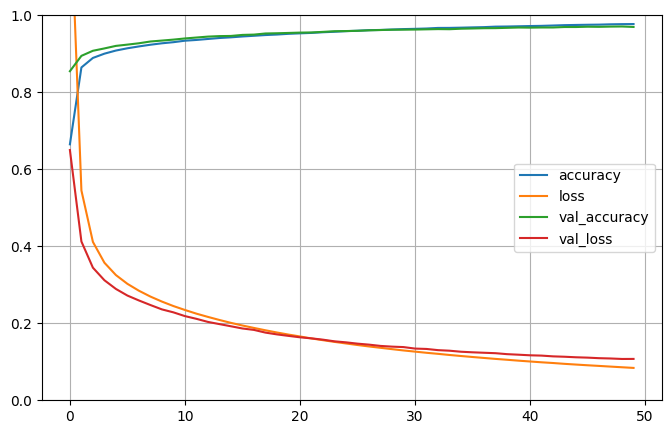

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Si el modelo no ha ido bien, prueba a cambiar el learning rate, cambia de optimizador y después prueba a cambiar capas, neuronas y funciones de activación.

Ya tenemos el modelo entrenado. Probémoslo con test

In [ ]:
results = model.evaluate(X_test, y_test)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9728 - loss: 0.0886


[0.08856586366891861, 0.9728000164031982]

C:\Users\titea\AppData\Local\Temp\ipykernel_2168\1468152043.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


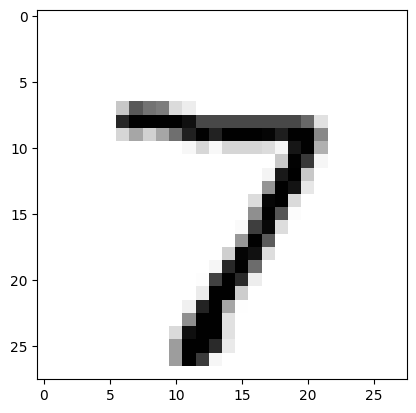

In [ ]:
# Cogemos el primero
plt.imshow(X_test[0].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [ ]:
X_test[:1]

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.

In [ ]:
predictions = model.predict(X_test[:1])
print(predictions.shape)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(1, 10)


array([[4.2535880e-06, 2.1233728e-07, 7.0330905e-05, 8.1746926e-04,
        1.8192448e-08, 3.1504676e-06, 8.0247142e-11, 9.9906260e-01,
        2.4590406e-06, 3.9539114e-05]], dtype=float32)

In [ ]:
predictions.argmax()

np.int64(7)

In [ ]:
model.predict(X_test).argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

C:\Users\titea\AppData\Local\Temp\ipykernel_2168\4029188365.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));


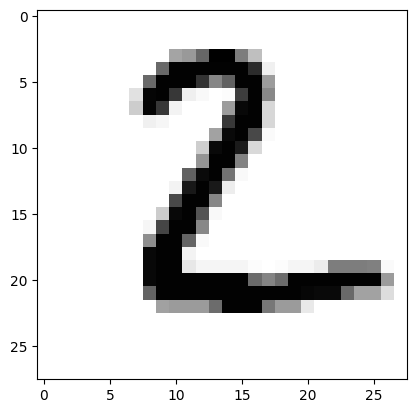

In [ ]:
plt.imshow(X_test[1].reshape(28,28), cmap=plt.cm.get_cmap('Greys'));

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).argmax(axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step


array([[ 964,    0,    1,    1,    1,    3,    4,    4,    2,    0],
       [   0, 1124,    3,    1,    0,    2,    3,    0,    2,    0],
       [   5,    2, 1007,    3,    1,    0,    2,    6,    6,    0],
       [   0,    0,    4,  989,    0,    6,    0,    4,    5,    2],
       [   1,    0,    5,    0,  950,    0,    3,    2,    2,   19],
       [   6,    1,    0,    7,    2,  863,    7,    1,    3,    2],
       [   5,    3,    1,    0,    6,   11,  927,    0,    5,    0],
       [   0,    9,    9,    3,    0,    1,    0,  998,    0,    8],
       [   4,    0,    5,   11,    3,    7,    4,    3,  935,    2],
       [   4,    6,    2,    7,    9,    1,    0,    7,    2,  971]])

### Problema de regresión
Veamos un ejemplo de cómo aplicar una red neuronal de TensorFlow a un problema de regresión.

In [ ]:
# Cargamos datos
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns = housing.feature_names)
df['target'] = housing['target']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Divimos en train, test y validation

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data,
                                                              housing.target)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,
                                                      y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape

(11610, 8)

Montamos el modelo. Simplemente se compondrá de una hidden layer, a la que le configuramos una capa previa de entrada de 8 neuronas (las features).

Se trata de un modelo de regresión, por lo que la capa de salida es una única neurona.

In [ ]:
11610/32

362.8125

In [ ]:
X_train.shape

(11610, 8)

In [ ]:
X_train.shape[1:]

(8,)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation = 'relu', # 30 neuronas la capa intermedia
                      input_shape = X_train.shape[1:]),
    keras.layers.Dense(1) # no pasa por activación porque es regresión, no fae falta
])

model.compile(loss = "mean_squared_error",
             optimizer = "sgd")

history = model.fit(X_train,
                   y_train,
                   epochs = 20,
                   validation_data = (X_valid, y_valid))

Epoch 1/20
  1/363 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - loss: 4.2730

c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4801 - val_loss: 0.5793
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4825 - val_loss: 0.4675
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4353 - val_loss: 0.4387
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4178 - val_loss: 0.4309
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4080 - val_loss: 0.4153
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4006 - val_loss: 0.4026
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3953 - val_loss: 0.4156
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3896 - val_loss: 0.3914
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3865 - val_loss: 0.3936
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3831 - val_loss: 0.3849
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3814 - val_loss: 0.3836
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.

In [ ]:
8*30 + 30

270

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.19 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
8*30+30

270

In [ ]:
mse_test = model.evaluate(X_test, y_test)
print(mse_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 0.3705
0.37045925855636597


In [ ]:
y_pred = model.predict(X_test[:5]) # model predict de las 5 primeras casas
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[2.2259648],
       [4.086462 ],
       [2.7922304],
       [3.5250108],
       [2.4707212]], dtype=float32)

### Guardar modelo
Para guardar el modelo, en el formato de Keras (HDF5). 

In [ ]:
model.save("my_keras_model.keras")

In [ ]:
# Lo volvemos a cargar
model = keras.models.load_model("my_keras_model.keras")

### Callbacks
Son funciones predefinidas de Keras a aplicar durante el entrenamiento
Por ejemplo, `ModelCheckpoint` sirve para que el modelo se vaya guardando tras cada epoch. Así no perdemos el progreso en caso de que decidamos interrumpir el entrenamiento. El callback recibe como argumento el nombre del objeto donde queremos que se guarde el modelo entrenado.

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("callback_model.keras")
history = model.fit(X_train,
                   y_train,
                   epochs=30,
                   callbacks = [checkpoint_cb])

Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 0.3613
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 0.3611
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.3578
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 0.3566
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 0.3562
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.3551
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 0.3536
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.3526
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - loss: 0.3519
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 0.3504
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - loss: 0.3498
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.3487
Epoch 13/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 0.3478
Epoch 14/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - loss: 0.3461
Epoch 15/30
363/363 ━━━━━━━━━

### Early Stopping
Interrumpe el entrenamiento cuando no ve progreso en el set de validación. Para ello tiene en cuenta un numero de epochs llamado `patience`. Se puede combinar con el callback

In [ ]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10) # antes de pararte, haz 10 iteraciones consecutivas en las que no mejores
history = model.fit(X_train,
                   y_train,
                   epochs=50,
                   validation_data = (X_valid, y_valid),
                   callbacks = [early_stopping_cb, checkpoint_cb])

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3264 - val_loss: 0.3355
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3264 - val_loss: 0.3442
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3266 - val_loss: 0.3349
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3250 - val_loss: 0.3444
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3243 - val_loss: 0.3355
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3234 - val_loss: 0.3367
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3223 - val_loss: 0.3324
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3207 - val_loss: 0.3435
Epoch 9/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3200 - val_loss: 0.3394
Epoch 10/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3199 - val_loss: 0.3317
Epoch 11/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3196 - val_loss: 0.3326
Epoch 12/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

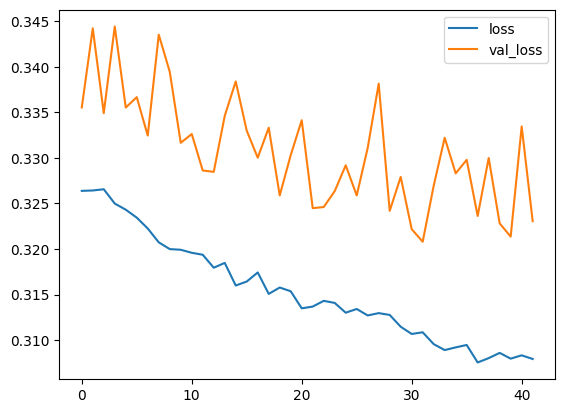

In [ ]:
history_df = pd.DataFrame(history.history).plot()